Первостепенно начну с загрузки и анализа данных

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN
from sklearn.ensemble import IsolationForest
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Фиксирую random_state для воспроизводимости
np.random.seed(42)

# Загрузка данных
df = pd.read_csv('skab_valve_1.csv', sep=';')

Пропущенные значения:
Accelerometer1RMS      0
Accelerometer2RMS      0
Current                0
Pressure               0
Temperature            0
Thermocouple           0
Voltage                0
Volume Flow RateRMS    0
anomaly                0
changepoint            0
dtype: int64


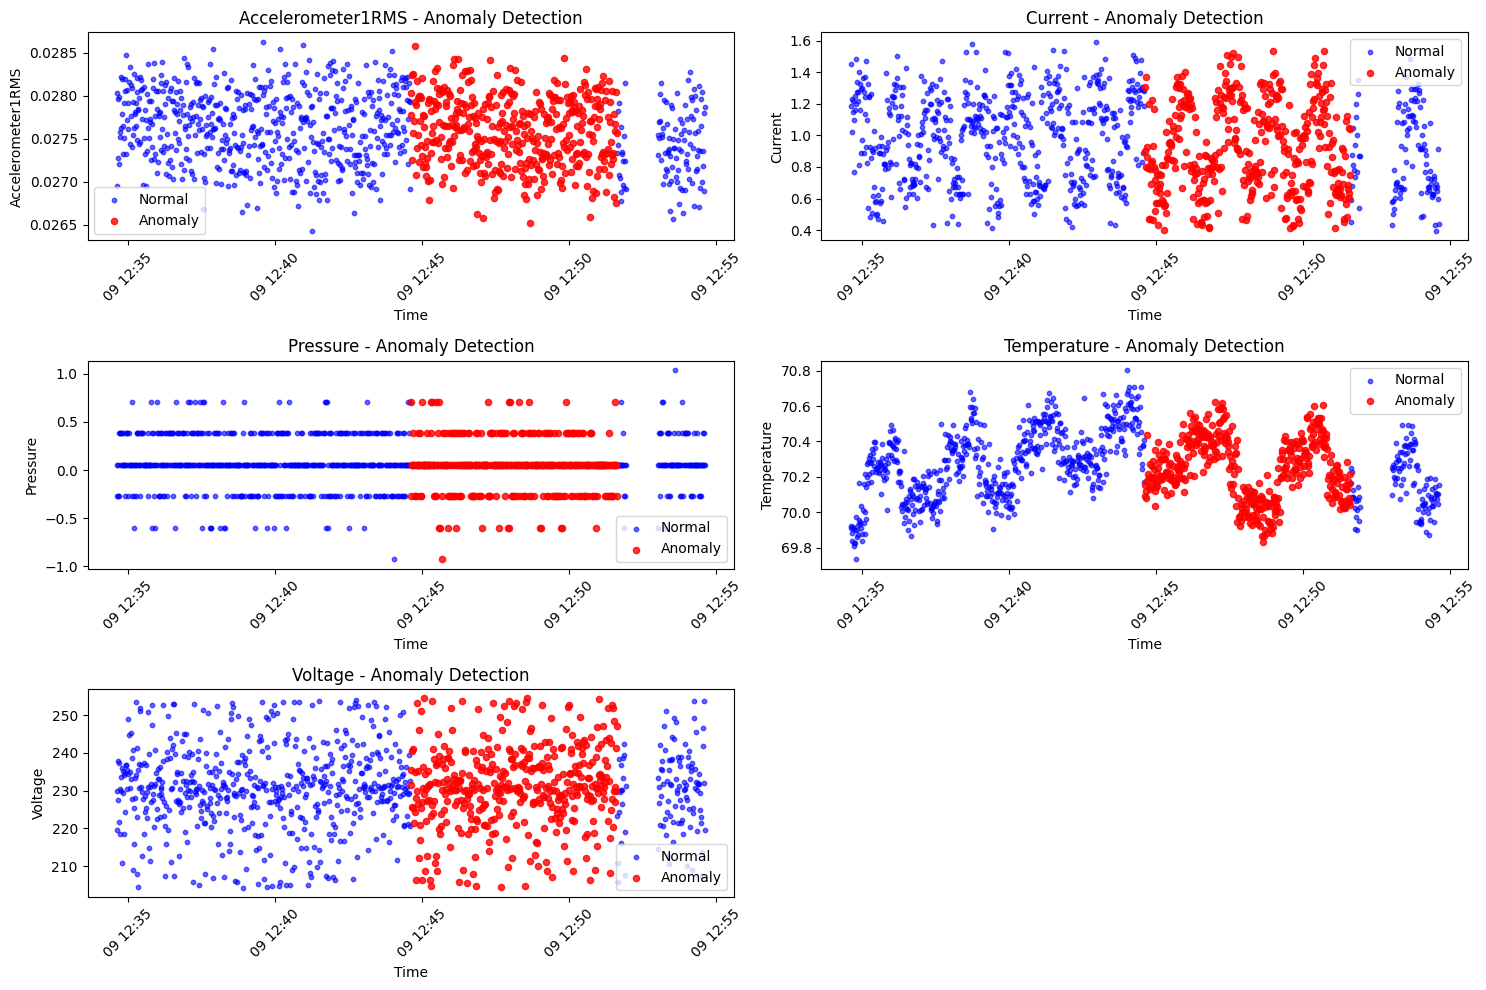

Всего записей: 1094
Аномалий: 405.0 (37.02%)
Точек изменения: 4.0


In [4]:
# Преобразуем datetime в правильный формат
df['datetime'] = pd.to_datetime(df['datetime'])
df = df.set_index('datetime')

# Проверим наличие пропущенных значений
print("Пропущенные значения:")
print(df.isnull().sum())

# Визуализация исходных данных с выделением аномалий
plt.figure(figsize=(15, 10))

# Выберем несколько ключевых параметров для визуализации
key_columns = ['Accelerometer1RMS', 'Current', 'Pressure', 'Temperature', 'Voltage']

for i, col in enumerate(key_columns, 1):
    plt.subplot(3, 2, i)

    # Нормальные точки
    normal_data = df[df['anomaly'] == 0]
    plt.scatter(normal_data.index, normal_data[col],
                alpha=0.6, s=10, label='Normal', c='blue')

    # Аномальные точки
    anomaly_data = df[df['anomaly'] == 1]
    if not anomaly_data.empty:
        plt.scatter(anomaly_data.index, anomaly_data[col],
                    alpha=0.8, s=20, label='Anomaly', c='red')

    plt.title(f'{col} - Anomaly Detection')
    plt.xlabel('Time')
    plt.ylabel(col)
    plt.legend()
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Статистика по аномалиям
print(f"Всего записей: {len(df)}")
print(f"Аномалий: {df['anomaly'].sum()} ({df['anomaly'].mean()*100:.2f}%)")
print(f"Точек изменения: {df['changepoint'].sum()}")

**Статистические эвристики (IQR метод)**

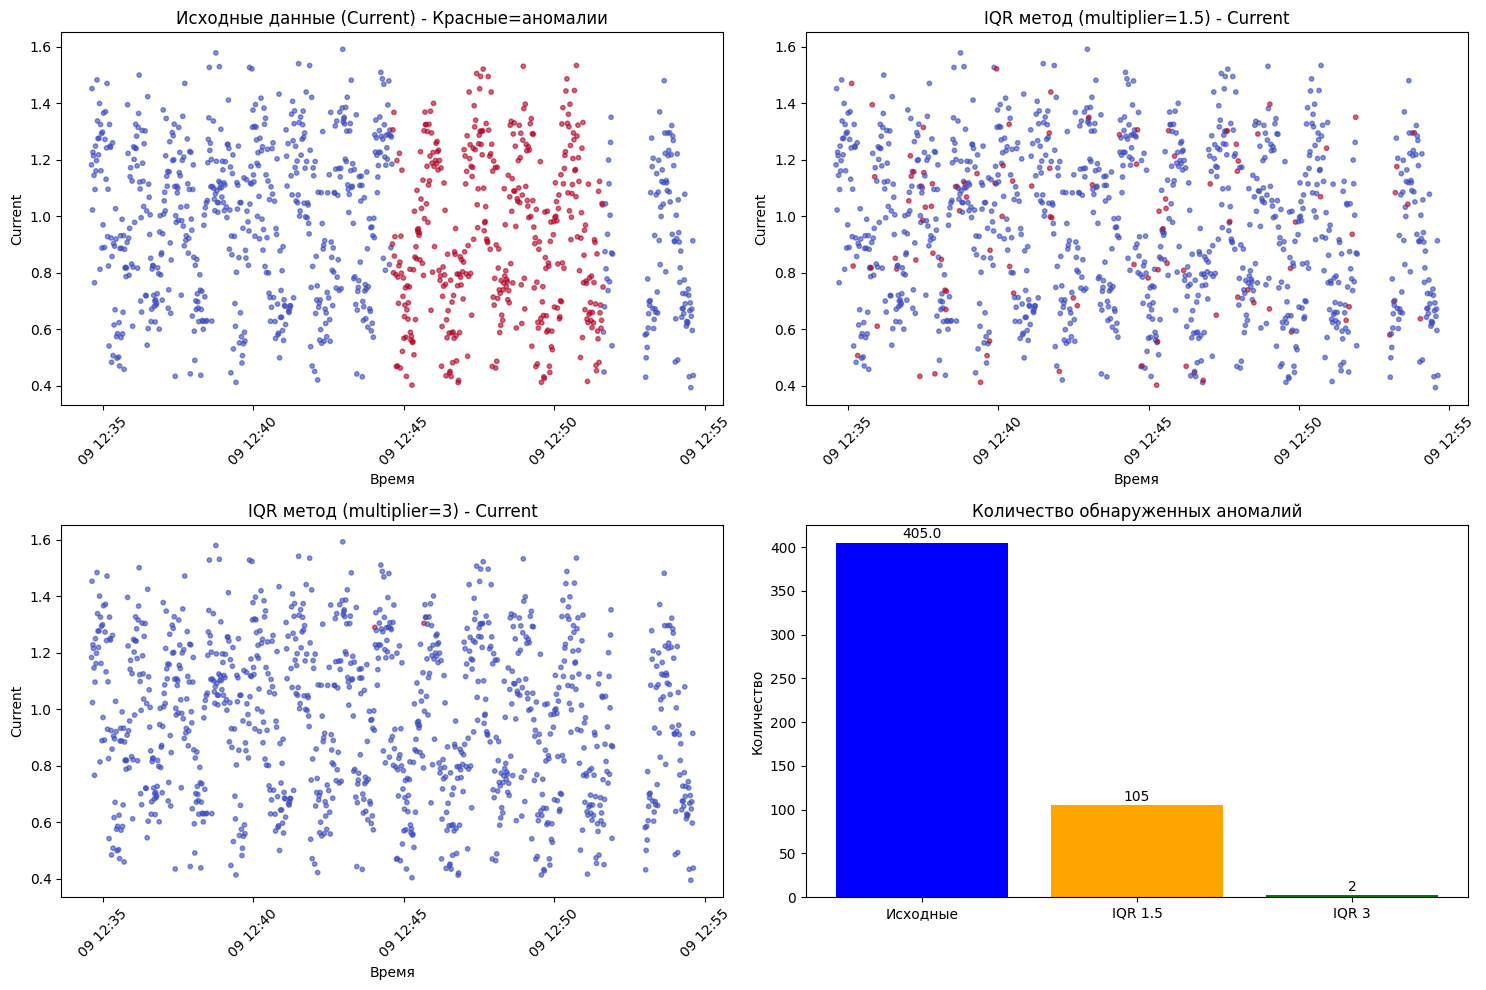

IQR метод (1.5):
[[620  69]
 [369  36]]
Report:
              precision    recall  f1-score   support

         0.0       0.63      0.90      0.74       689
         1.0       0.34      0.09      0.14       405

    accuracy                           0.60      1094
   macro avg       0.48      0.49      0.44      1094
weighted avg       0.52      0.60      0.52      1094

IQR метод (3):
[[688   1]
 [404   1]]
Report:
              precision    recall  f1-score   support

         0.0       0.63      1.00      0.77       689
         1.0       0.50      0.00      0.00       405

    accuracy                           0.63      1094
   macro avg       0.57      0.50      0.39      1094
weighted avg       0.58      0.63      0.49      1094



In [8]:
def detect_anomalies_iqr(data, columns, multiplier=1.5): # Обнаружение аномалий с помощью метода IQR
    anomalies = pd.Series([0] * len(data), index=data.index)

    for col in columns:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - multiplier * IQR
        upper_bound = Q3 + multiplier * IQR

        # Находим аномалии для текущего признака
        col_anomalies = (data[col] < lower_bound) | (data[col] > upper_bound)
        anomalies = anomalies | col_anomalies

    return anomalies.astype(int)

# Применяем IQR метод с разными множителями
numeric_columns = ['Accelerometer1RMS', 'Accelerometer2RMS', 'Current',
                   'Pressure', 'Temperature', 'Thermocouple', 'Voltage',
                   'Volume Flow RateRMS']

# IQR с множителем 1.5
iqr_15_anomalies = detect_anomalies_iqr(df, numeric_columns, multiplier=1.5)

# IQR с множителем 3
iqr_3_anomalies = detect_anomalies_iqr(df, numeric_columns, multiplier=3)

# Визуализация результатов IQR метода
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Исходные аномалии
axes[0, 0].scatter(df.index, df['Current'], c=df['anomaly'],
                   cmap='coolwarm', alpha=0.6, s=10)
axes[0, 0].set_title('Исходные данные (Current) - Красные=аномалии')
axes[0, 0].set_xlabel('Время')
axes[0, 0].set_ylabel('Current')
axes[0, 0].tick_params(axis='x', rotation=45)

# IQR 1.5
axes[0, 1].scatter(df.index, df['Current'], c=iqr_15_anomalies,
                   cmap='coolwarm', alpha=0.6, s=10)
axes[0, 1].set_title('IQR метод (multiplier=1.5) - Current')
axes[0, 1].set_xlabel('Время')
axes[0, 1].set_ylabel('Current')
axes[0, 1].tick_params(axis='x', rotation=45)

# IQR 3
axes[1, 0].scatter(df.index, df['Current'], c=iqr_3_anomalies,
                   cmap='coolwarm', alpha=0.6, s=10)
axes[1, 0].set_title('IQR метод (multiplier=3) - Current')
axes[1, 0].set_xlabel('Время')
axes[1, 0].set_ylabel('Current')
axes[1, 0].tick_params(axis='x', rotation=45)

# Сравнение количества аномалий
methods = ['Исходные', 'IQR 1.5', 'IQR 3']
counts = [df['anomaly'].sum(), iqr_15_anomalies.sum(), iqr_3_anomalies.sum()]

axes[1, 1].bar(methods, counts, color=['blue', 'orange', 'green'])
axes[1, 1].set_title('Количество обнаруженных аномалий')
axes[1, 1].set_ylabel('Количество')

for i, v in enumerate(counts):
    axes[1, 1].text(i, v + 5, str(v), ha='center')

plt.tight_layout()
plt.show()

# Матрицы ошибок для IQR методов
print("IQR метод (1.5):")
print(confusion_matrix(df['anomaly'], iqr_15_anomalies))
print("Report:")
print(classification_report(df['anomaly'], iqr_15_anomalies))

print("IQR метод (3):")
print(confusion_matrix(df['anomaly'], iqr_3_anomalies))
print("Report:")
print(classification_report(df['anomaly'], iqr_3_anomalies))

**Кластеризация с созданием доп. признаков (Feature Engineering)**

Размерность после feature engineering: (1090, 77)
Объясненная дисперсия PCA: [0.10959686 0.07750289]


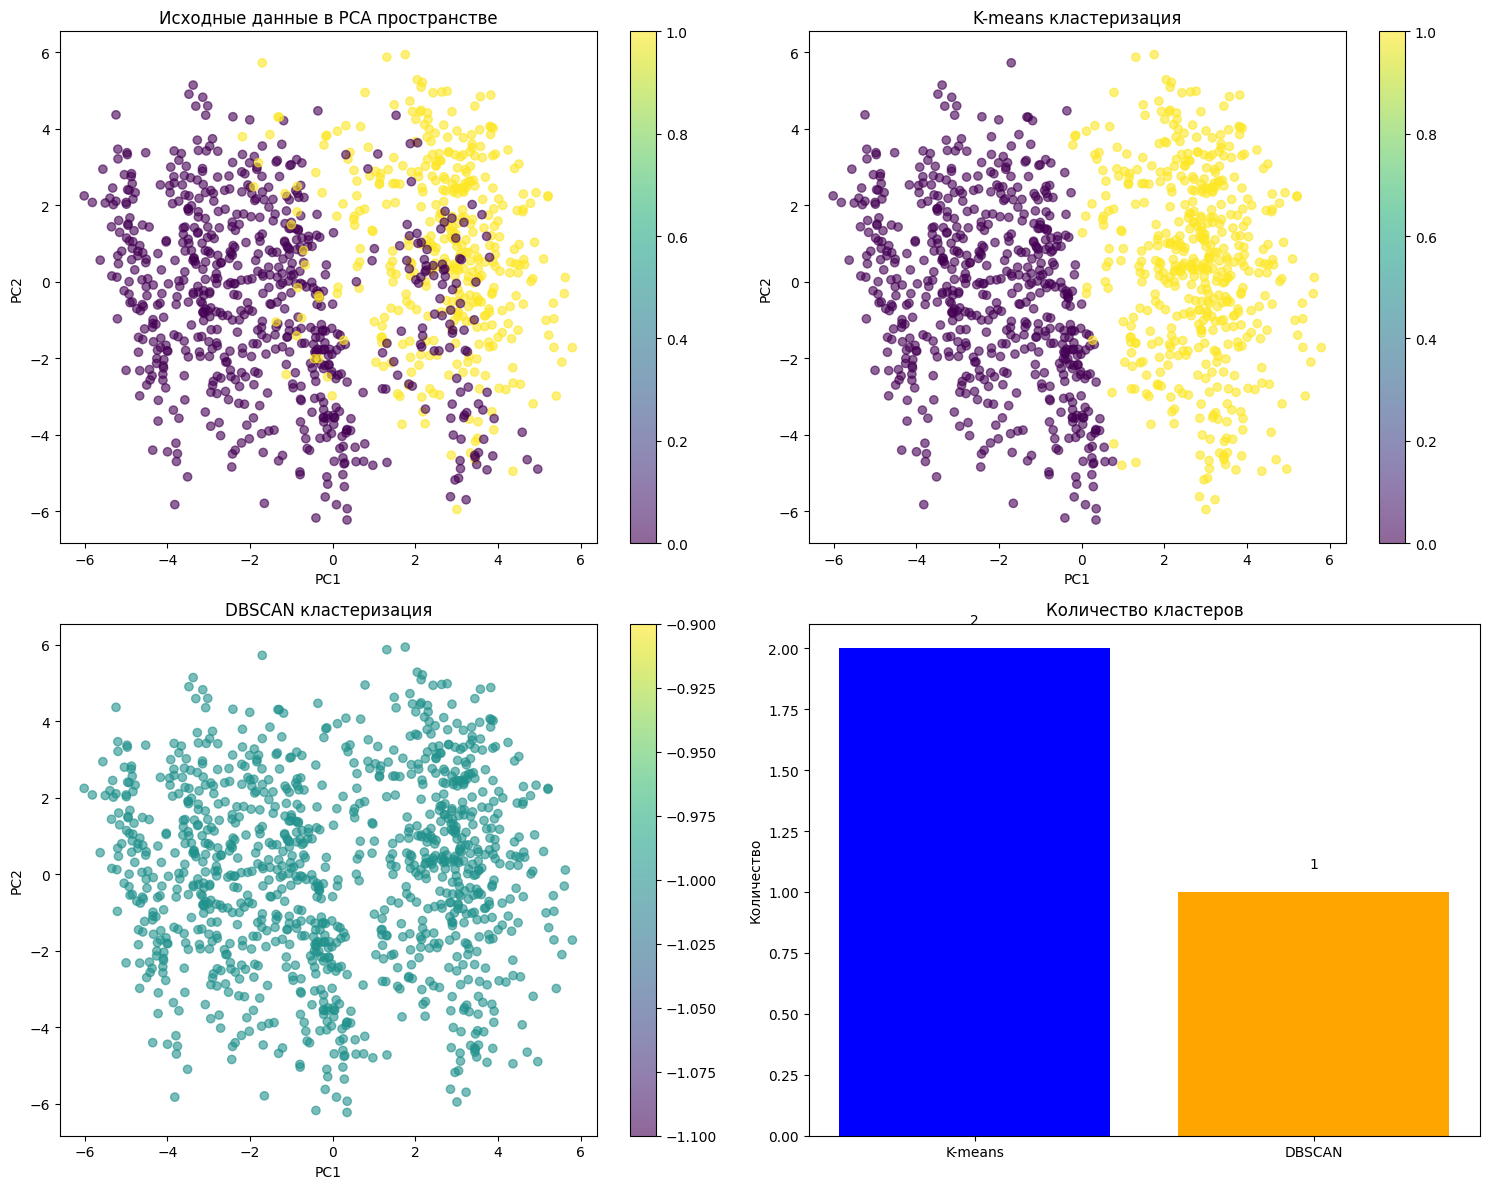

In [11]:
def create_features(data): # Создание дополнительных признаков для улучшения кластеризации
    features = data.copy()

    # Лаги (запаздывающие значения)
    for col in numeric_columns:
        features[f'{col}_lag1'] = features[col].shift(1)
        features[f'{col}_lag2'] = features[col].shift(2)
        features[f'{col}_lag3'] = features[col].shift(3)

    # Скользящие статистики
    window_size = 5
    for col in numeric_columns:
        features[f'{col}_rolling_mean'] = features[col].rolling(window=window_size).mean()
        features[f'{col}_rolling_std'] = features[col].rolling(window=window_size).std()
        features[f'{col}_rolling_range'] = (features[col].rolling(window=window_size).max() -
                                          features[col].rolling(window=window_size).min())

    # Производные (изменения)
    for col in numeric_columns:
        features[f'{col}_diff1'] = features[col].diff(1)
        features[f'{col}_diff2'] = features[col].diff(2)

    # Временные признаки
    features['hour'] = features.index.hour
    features['minute'] = features.index.minute
    features['second'] = features.index.second

    # Взаимодействия признаков
    features['accel_product'] = features['Accelerometer1RMS'] * features['Accelerometer2RMS']
    features['power_approx'] = features['Current'] * features['Voltage']

    # Удаляем строки с NaN (из-за лагов и скользящих окон)
    features = features.dropna()

    return features

# Создаем расширенный набор признаков
extended_features = create_features(df[numeric_columns])
print(f"Размерность после feature engineering: {extended_features.shape}")

# Стандартизация признаков
scaler = StandardScaler()
scaled_features = scaler.fit_transform(extended_features)

# Применяем PCA для визуализации
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_features)

print(f"Объясненная дисперсия PCA: {pca.explained_variance_ratio_}")

# Кластеризация с помощью K-means
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans_labels = kmeans.fit_predict(scaled_features)

# Кластеризация с помощью DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=10)
dbscan_labels = dbscan.fit_predict(scaled_features)

# Визуализация кластеризации
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Исходные данные в PCA пространстве
scatter0 = axes[0, 0].scatter(pca_result[:, 0], pca_result[:, 1],
                             c=df.loc[extended_features.index, 'anomaly'],
                             cmap='viridis', alpha=0.6)
axes[0, 0].set_title('Исходные данные в PCA пространстве')
axes[0, 0].set_xlabel('PC1')
axes[0, 0].set_ylabel('PC2')
plt.colorbar(scatter0, ax=axes[0, 0])

# K-means кластеризация
scatter1 = axes[0, 1].scatter(pca_result[:, 0], pca_result[:, 1],
                             c=kmeans_labels, cmap='viridis', alpha=0.6)
axes[0, 1].set_title('K-means кластеризация')
axes[0, 1].set_xlabel('PC1')
axes[0, 1].set_ylabel('PC2')
plt.colorbar(scatter1, ax=axes[0, 1])

# DBSCAN кластеризация
scatter2 = axes[1, 0].scatter(pca_result[:, 0], pca_result[:, 1],
                             c=dbscan_labels, cmap='viridis', alpha=0.6)
axes[1, 0].set_title('DBSCAN кластеризация')
axes[1, 0].set_xlabel('PC1')
axes[1, 0].set_ylabel('PC2')
plt.colorbar(scatter2, ax=axes[1, 0])

# Сравнение методов кластеризации
cluster_counts = [len(np.unique(kmeans_labels)), len(np.unique(dbscan_labels))]
axes[1, 1].bar(['K-means', 'DBSCAN'], cluster_counts, color=['blue', 'orange'])
axes[1, 1].set_title('Количество кластеров')
axes[1, 1].set_ylabel('Количество')

for i, v in enumerate(cluster_counts):
    axes[1, 1].text(i, v + 0.1, str(v), ha='center')

plt.tight_layout()
plt.show()

*Обнаружение аномалий на основе кластеризации*

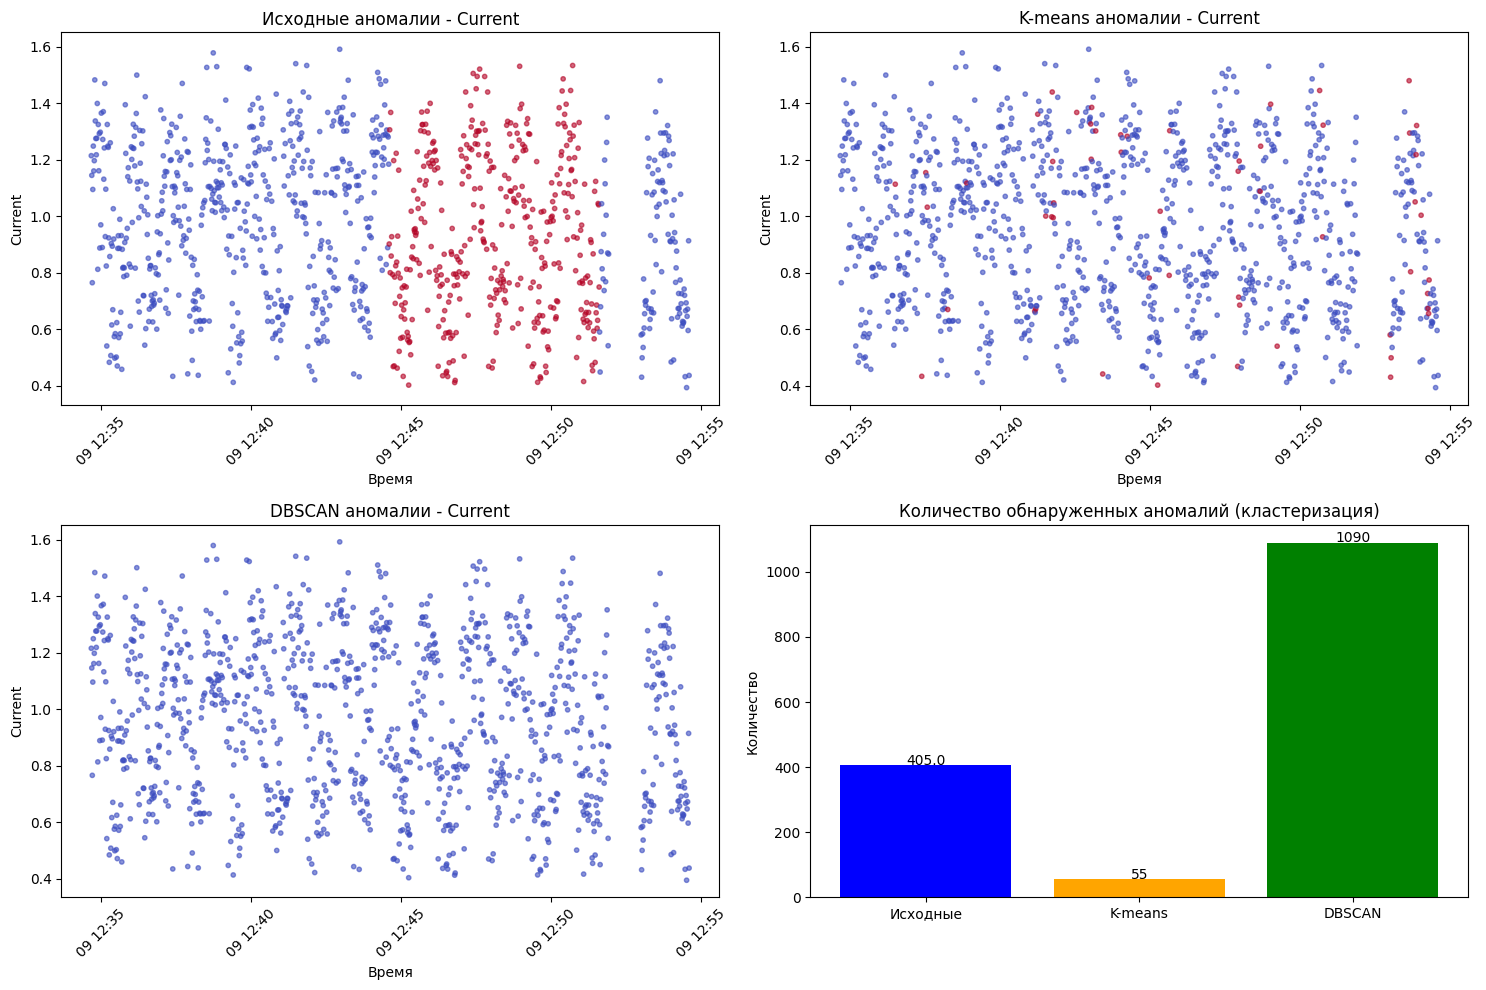

K-means кластеризация:
[[647  38]
 [388  17]]
Report:
              precision    recall  f1-score   support

         0.0       0.63      0.94      0.75       685
         1.0       0.31      0.04      0.07       405

    accuracy                           0.61      1090
   macro avg       0.47      0.49      0.41      1090
weighted avg       0.51      0.61      0.50      1090

DBSCAN кластеризация:
[[  0 685]
 [  0 405]]
Report:
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00       685
         1.0       0.37      1.00      0.54       405

    accuracy                           0.37      1090
   macro avg       0.19      0.50      0.27      1090
weighted avg       0.14      0.37      0.20      1090



In [13]:
# Для K-means: аномалии - точки, наиболее удаленные от центроидов
kmeans_distances = kmeans.transform(scaled_features)
kmeans_anomaly_scores = np.min(kmeans_distances, axis=1)
kmeans_threshold = np.percentile(kmeans_anomaly_scores, 95)  # 5% самых удаленных как аномалии
kmeans_anomalies = (kmeans_anomaly_scores > kmeans_threshold).astype(int)

# Для DBSCAN: аномалии - шумовые точки (label = -1)
dbscan_anomalies = (dbscan_labels == -1).astype(int)

# Создаем Series с аномалиями (с учетом удаленных строк)
kmeans_anomalies_series = pd.Series(kmeans_anomalies, index=extended_features.index)
dbscan_anomalies_series = pd.Series(dbscan_anomalies, index=extended_features.index)

# Визуализация результатов кластеризации
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Исходные аномалии (только для соответствующих индексов)
original_anomalies_subset = df.loc[extended_features.index, 'anomaly']
axes[0, 0].scatter(extended_features.index, extended_features['Current'],
                   c=original_anomalies_subset, cmap='coolwarm', alpha=0.6, s=10)
axes[0, 0].set_title('Исходные аномалии - Current')
axes[0, 0].set_xlabel('Время')
axes[0, 0].set_ylabel('Current')
axes[0, 0].tick_params(axis='x', rotation=45)

# K-means аномалии
axes[0, 1].scatter(extended_features.index, extended_features['Current'],
                   c=kmeans_anomalies, cmap='coolwarm', alpha=0.6, s=10)
axes[0, 1].set_title('K-means аномалии - Current')
axes[0, 1].set_xlabel('Время')
axes[0, 1].set_ylabel('Current')
axes[0, 1].tick_params(axis='x', rotation=45)

# DBSCAN аномалии
axes[1, 0].scatter(extended_features.index, extended_features['Current'],
                   c=dbscan_anomalies, cmap='coolwarm', alpha=0.6, s=10)
axes[1, 0].set_title('DBSCAN аномалии - Current')
axes[1, 0].set_xlabel('Время')
axes[1, 0].set_ylabel('Current')
axes[1, 0].tick_params(axis='x', rotation=45)

# Сравнение количества аномалий
cluster_methods = ['Исходные', 'K-means', 'DBSCAN']
cluster_counts = [original_anomalies_subset.sum(), kmeans_anomalies.sum(), dbscan_anomalies.sum()]

axes[1, 1].bar(cluster_methods, cluster_counts, color=['blue', 'orange', 'green'])
axes[1, 1].set_title('Количество обнаруженных аномалий (кластеризация)')
axes[1, 1].set_ylabel('Количество')

for i, v in enumerate(cluster_counts):
    axes[1, 1].text(i, v + 2, str(v), ha='center')

plt.tight_layout()
plt.show()

# Матрицы ошибок для методов кластеризации
print("K-means кластеризация:")
print(confusion_matrix(original_anomalies_subset, kmeans_anomalies))
print("Report:")
print(classification_report(original_anomalies_subset, kmeans_anomalies))

print("DBSCAN кластеризация:")
print(confusion_matrix(original_anomalies_subset, dbscan_anomalies))
print("Report:")
print(classification_report(original_anomalies_subset, dbscan_anomalies))

**Isolation Forest**

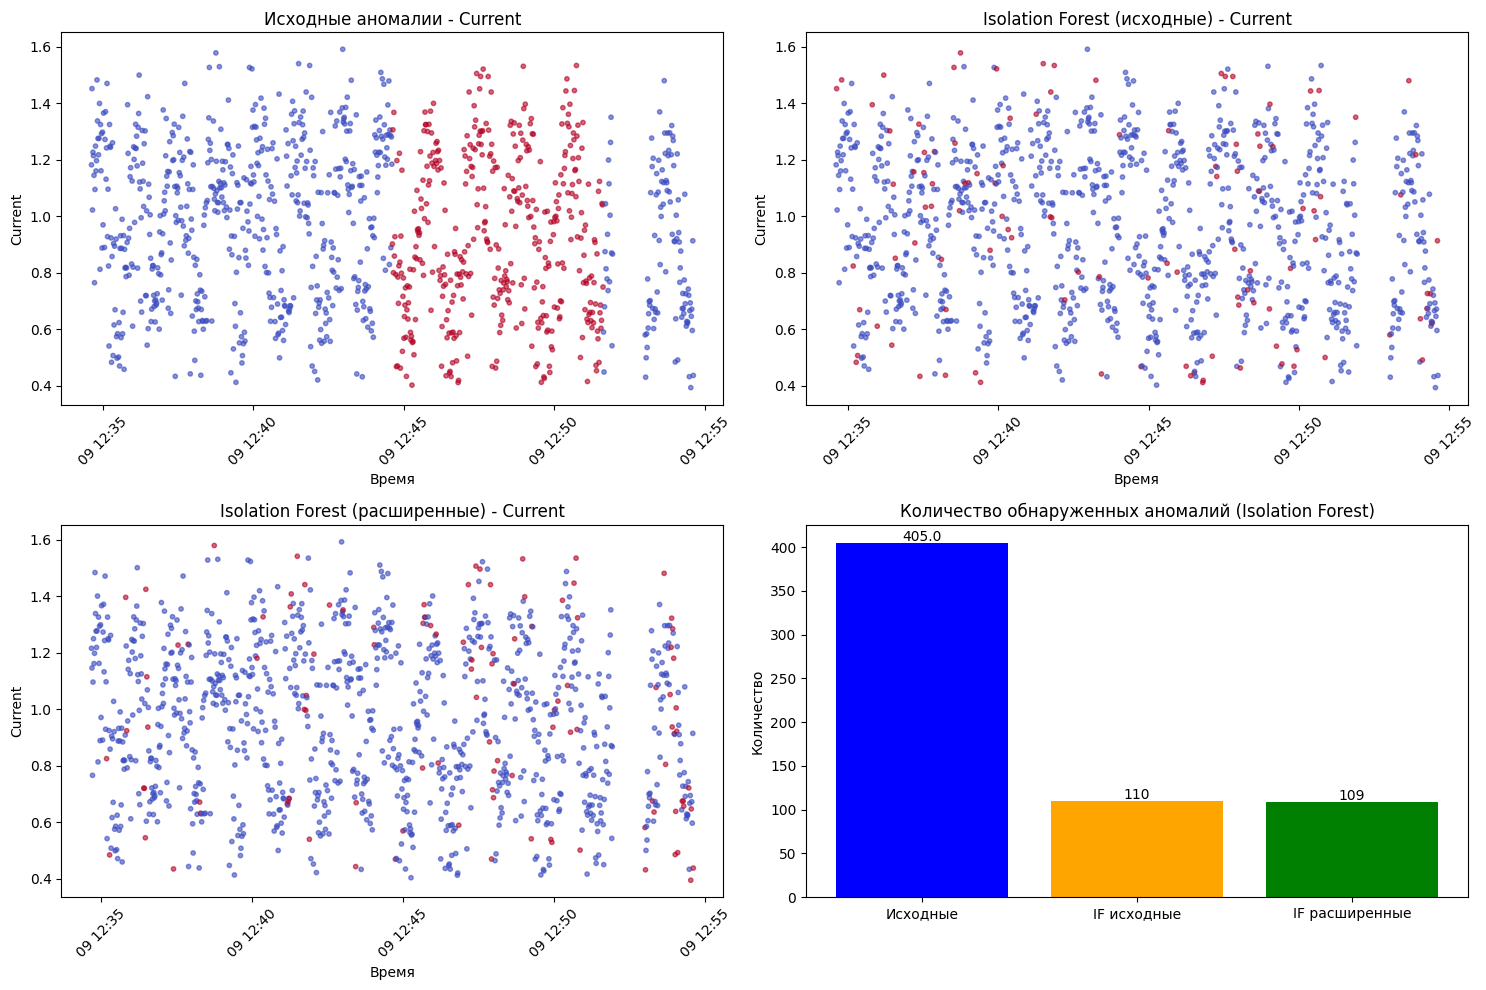

Isolation Forest (исходные признаки):
[[622  67]
 [362  43]]
Report:
              precision    recall  f1-score   support

         0.0       0.63      0.90      0.74       689
         1.0       0.39      0.11      0.17       405

    accuracy                           0.61      1094
   macro avg       0.51      0.50      0.46      1094
weighted avg       0.54      0.61      0.53      1094

Isolation Forest (расширенные признаки):
[[623  62]
 [358  47]]
Report:
              precision    recall  f1-score   support

         0.0       0.64      0.91      0.75       685
         1.0       0.43      0.12      0.18       405

    accuracy                           0.61      1090
   macro avg       0.53      0.51      0.47      1090
weighted avg       0.56      0.61      0.54      1090



In [15]:
# Isolation Forest для обнаружения аномалий
iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.1,  # предполагаемая доля аномалий
    random_state=42,
    n_jobs=-1
)

# Обучаем на исходных данных (без feature engineering)
iso_predictions = iso_forest.fit_predict(df[numeric_columns])
# Преобразуем предсказания: 1 = норма, -1 = аномалия -> 0 = норма, 1 = аномалия
iso_anomalies = (iso_predictions == -1).astype(int)

# Isolation Forest на расширенных признаках
iso_forest_extended = IsolationForest(
    n_estimators=100,
    contamination=0.1,
    random_state=42,
    n_jobs=-1
)

iso_predictions_extended = iso_forest_extended.fit_predict(scaled_features)
iso_anomalies_extended = (iso_predictions_extended == -1).astype(int)

# Визуализация результатов Isolation Forest
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Исходные аномалии
axes[0, 0].scatter(df.index, df['Current'], c=df['anomaly'],
                   cmap='coolwarm', alpha=0.6, s=10)
axes[0, 0].set_title('Исходные аномалии - Current')
axes[0, 0].set_xlabel('Время')
axes[0, 0].set_ylabel('Current')
axes[0, 0].tick_params(axis='x', rotation=45)

# Isolation Forest (исходные признаки)
axes[0, 1].scatter(df.index, df['Current'], c=iso_anomalies,
                   cmap='coolwarm', alpha=0.6, s=10)
axes[0, 1].set_title('Isolation Forest (исходные) - Current')
axes[0, 1].set_xlabel('Время')
axes[0, 1].set_ylabel('Current')
axes[0, 1].tick_params(axis='x', rotation=45)

# Isolation Forest (расширенные признаки)
axes[1, 0].scatter(extended_features.index, extended_features['Current'],
                   c=iso_anomalies_extended, cmap='coolwarm', alpha=0.6, s=10)
axes[1, 0].set_title('Isolation Forest (расширенные) - Current')
axes[1, 0].set_xlabel('Время')
axes[1, 0].set_ylabel('Current')
axes[1, 0].tick_params(axis='x', rotation=45)

# Сравнение количества аномалий
iso_methods = ['Исходные', 'IF исходные', 'IF расширенные']
iso_counts = [df['anomaly'].sum(), iso_anomalies.sum(), iso_anomalies_extended.sum()]

axes[1, 1].bar(iso_methods, iso_counts, color=['blue', 'orange', 'green'])
axes[1, 1].set_title('Количество обнаруженных аномалий (Isolation Forest)')
axes[1, 1].set_ylabel('Количество')

for i, v in enumerate(iso_counts):
    axes[1, 1].text(i, v + 2, str(v), ha='center')

plt.tight_layout()
plt.show()

# Матрицы ошибок для Isolation Forest
print("Isolation Forest (исходные признаки):")
print(confusion_matrix(df['anomaly'], iso_anomalies))
print("Report:")
print(classification_report(df['anomaly'], iso_anomalies))

print("Isolation Forest (расширенные признаки):")
print(confusion_matrix(original_anomalies_subset, iso_anomalies_extended))
print("Report:")
print(classification_report(original_anomalies_subset, iso_anomalies_extended))

*Сравнение всех методов*

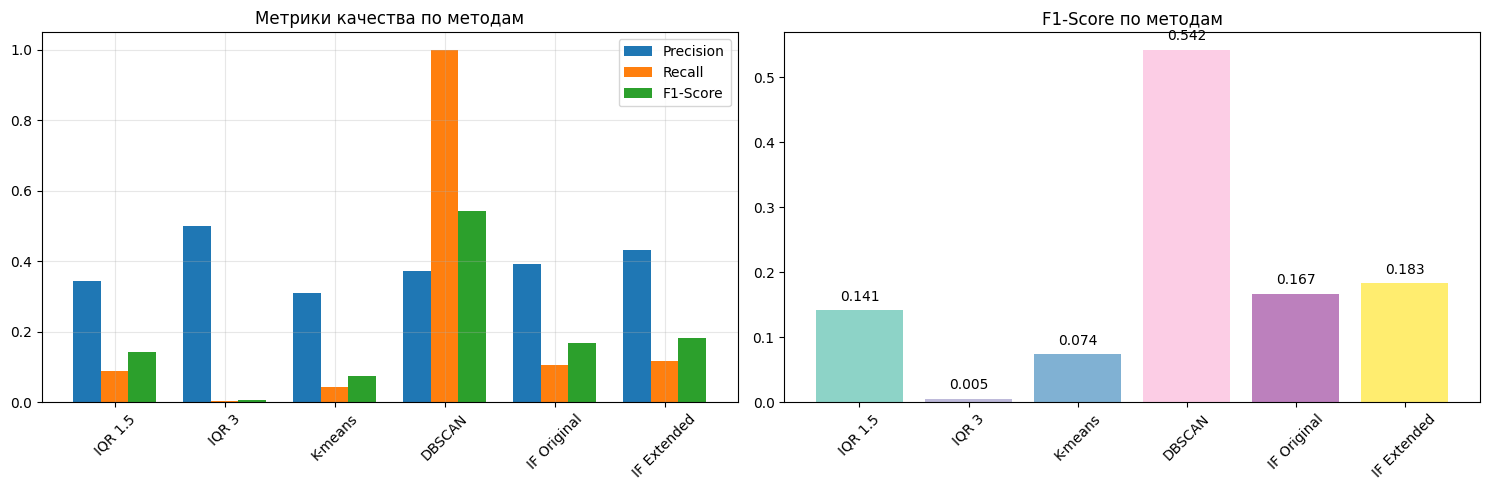

СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ:
     Method  Precision  Recall  F1-Score  Accuracy  TP  FP  FN
    IQR 1.5     0.3429  0.0889    0.1412    0.5996  36  69 369
      IQR 3     0.5000  0.0025    0.0049    0.6298   1   1 404
    K-means     0.3091  0.0420    0.0739    0.6092  17  38 388
     DBSCAN     0.3716  1.0000    0.5418    0.3716 405 685   0
IF Original     0.3909  0.1062    0.1670    0.6079  43  67 362
IF Extended     0.4312  0.1160    0.1829    0.6147  47  62 358
ЛУЧШИЙ МЕТОД: DBSCAN
F1-Score: 0.5418
Precision: 0.3716
Recall: 1.0000


In [18]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

def evaluate_model(true_labels, predicted_labels, method_name): # Оценка качества модели
    return {
        'Method': method_name,
        'Precision': precision_score(true_labels, predicted_labels, zero_division=0),
        'Recall': recall_score(true_labels, predicted_labels, zero_division=0),
        'F1-Score': f1_score(true_labels, predicted_labels, zero_division=0),
        'Accuracy': accuracy_score(true_labels, predicted_labels),
        'TP': confusion_matrix(true_labels, predicted_labels)[1, 1],
        'FP': confusion_matrix(true_labels, predicted_labels)[0, 1],
        'FN': confusion_matrix(true_labels, predicted_labels)[1, 0]
    }

# Собираю результаты всех методов
results = [
    evaluate_model(df['anomaly'], iqr_15_anomalies, 'IQR 1.5'),
    evaluate_model(df['anomaly'], iqr_3_anomalies, 'IQR 3'),
    evaluate_model(original_anomalies_subset, kmeans_anomalies, 'K-means'),
    evaluate_model(original_anomalies_subset, dbscan_anomalies, 'DBSCAN'),
    evaluate_model(df['anomaly'], iso_anomalies, 'IF Original'),
    evaluate_model(original_anomalies_subset, iso_anomalies_extended, 'IF Extended')
]

results_df = pd.DataFrame(results)

# Визуализация сравнения
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Основные метрики
metrics = ['Precision', 'Recall', 'F1-Score']
x_pos = np.arange(len(results_df))

for i, metric in enumerate(metrics):
    axes[0].bar(x_pos + i*0.25, results_df[metric], width=0.25, label=metric)

axes[0].set_title('Метрики качества по методам')
axes[0].set_xticks(x_pos + 0.25)
axes[0].set_xticklabels(results_df['Method'], rotation=45)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# F1-Score сравнение
colors = plt.cm.Set3(np.linspace(0, 1, len(results_df)))
bars = axes[1].bar(results_df['Method'], results_df['F1-Score'], color=colors)
axes[1].set_title('F1-Score по методам')
axes[1].tick_params(axis='x', rotation=45)

# Добавляю значения на столбцы
for bar, value in zip(bars, results_df['F1-Score']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{value:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Вывод результатов
print("СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ:")
print(results_df.round(4).to_string(index=False))

# Анализ лучшего метода
best_f1 = results_df.loc[results_df['F1-Score'].idxmax()]
print(f"ЛУЧШИЙ МЕТОД: {best_f1['Method']}")
print(f"F1-Score: {best_f1['F1-Score']:.4f}")
print(f"Precision: {best_f1['Precision']:.4f}")
print(f"Recall: {best_f1['Recall']:.4f}")

**Вывод**

Подводя итоги, можно вынести заключение для каждого метода.

Статистические методы (IQR) - простые и интерпретируемые, но могут пропускать сложные аномалии

Кластеризация - требует feature engineering, но может выявлять сложные паттерны

Isolation Forest - robust метод, хорошо справляется с различными типами аномалий

Каждый метод имеет свои плюсы и минусы, выбирать подход слеждует исходя из поставленной задачи и сложившейся ситуации.